# 미니프로젝트: 결측치·이상치·클래스 불균형 처리 (Vibe Coding)

#### <목표>
오늘 배운 **결측치/이상치 처리, Under/Oversampling, SVDD**를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- Telco Customer Churn (통신사 고객 이탈 데이터)
- 고객의 인적사항, 가입 서비스, 요금·계약 정보와 이탈(Churn) 여부를 담은 데이터

| 변수명 | 설명 |
|:---:|:---|
| gender, SeniorCitizen, Partner, Dependents | 고객 인적사항 |
| tenure | 가입 개월 수 |
| PhoneService, MultipleLines, InternetService 등 | 가입 서비스 종류 |
| Contract, PaperlessBilling, PaymentMethod | 계약/결제 정보 |
| MonthlyCharges, TotalCharges | 월/누적 요금 |
| Churn | 이탈 여부 (Yes: 이탈, No: 유지) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `Churn` | 고객 정보로 이탈 여부 예측 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day4_miniproject.csv` 파일을 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)

**[과제]** 써니는 통신사 고객 이탈 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리를 호출하고 데이터를 불러와 구조를 확인하는 코드를 AI와 상의해서 작성하세요.

In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# ===== 한글 폰트 설정 =====
FONT_CANDIDATES = [
    "/System/Library/Fonts/AppleSDGothicNeo.ttc",
    "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
    "C:/Windows/Fonts/malgun.ttf",
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
]
FONT_PATH = next((p for p in FONT_CANDIDATES if os.path.exists(p)), None)
if FONT_PATH:
    fm.fontManager.addfont(FONT_PATH)
    KOREAN_FONT = fm.FontProperties(fname=FONT_PATH)
    rcParams["font.family"] = KOREAN_FONT.get_name()
else:
    KOREAN_FONT = None

rcParams["axes.unicode_minus"] = False

# 데이터 로드
df = pd.read_csv("dataset/day4_miniproject.csv")
TARGET = "Churn"

print("데이터 크기:", df.shape)
print("\n컬럼 목록:")
print(df.columns.tolist())
df.head()

데이터 크기: (7043, 20)

컬럼 목록:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1) 데이터 탐색 (EDA)

### 1-1) 기본 EDA 진행

**[과제]** 써니는 데이터 분석 전, 데이터의 구조적 및 통계적 정보가 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [40]:
print("=== 기본 정보 ===")
df.info()

print("\n=== 수치형 변수 기술 통계 ===")
display(df.describe())

print("\n=== 범주형 변수 기술 통계 ===")
display(df.describe(include="object"))

=== 기본 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            6832 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   6903 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     6832 non-n

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,6832.000000,6832.000000,7032.000000
mean,0.162147,32.376903,64.758255,2283.300441
std,0.368612,24.570605,30.077758,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000



=== 범주형 변수 기술 통계 ===


,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,6903,7043,7043,7043,7043,7043,7043,7043,7043,6832,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3555,3641,4933,6361,3390,3033,3498,3088,3095,3473,2810,2785,3875,4171,2296,5174


**[과제]** 써니는 EDA를 통해 전처리가 필요한 부분을 발견했습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

> Tip: 'Churn' 변수의 타입이나 값 표기 방식

In [41]:
# Churn 타겟 변수 확인
print("Churn dtype:", df[TARGET].dtype)
print("Churn 고유값:", df[TARGET].unique())
print("\nChurn 분포:")
print(df[TARGET].value_counts())

# TotalCharges는 문자열로 저장된 공백/숫자 혼재 가능
print("\nTotalCharges dtype:", df["TotalCharges"].dtype)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges 숫자 변환 후 결측:", df["TotalCharges"].isna().sum())

# SeniorCitizen은 0/1 수치이지만 범주형 의미
print("\nSeniorCitizen 분포:")
print(df["SeniorCitizen"].value_counts())

print("\n[전처리 필요 사항 요약]")
print("- Churn: Yes/No 문자열 → 모델 학습용 0/1 인코딩 필요")
print("- TotalCharges: 숫자 변환 및 결측 대치 필요")
print("- 일부 행에 tenure, InternetService 등 결측 존재 → 대치 또는 삭제 검토")

Churn dtype: object
Churn 고유값: ['No' 'Yes']

Churn 분포:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

TotalCharges dtype: float64
TotalCharges 숫자 변환 후 결측: 11

SeniorCitizen 분포:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

[전처리 필요 사항 요약]
- Churn: Yes/No 문자열 → 모델 학습용 0/1 인코딩 필요
- TotalCharges: 숫자 변환 및 결측 대치 필요
- 일부 행에 tenure, InternetService 등 결측 존재 → 대치 또는 삭제 검토


### 1-2) 결측치 현황 파악

**[과제]** 써니는 데이터에 결측치가 존재하는지, 존재한다면 어떤 형태로 얼마나 있는지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

전체 결측치 개수: 784
전체 결측 비율: 0.56%

=== 변수별 결측치 요약 ===


,결측개수,결측비율(%),dtype
tenure,211,3.00,float64
PaymentMethod,211,3.00,object
MonthlyCharges,211,3.00,float64
InternetService,140,1.99,object
TotalCharges,11,0.16,float64



결측치가 하나라도 있는 행 비율: 10.83%


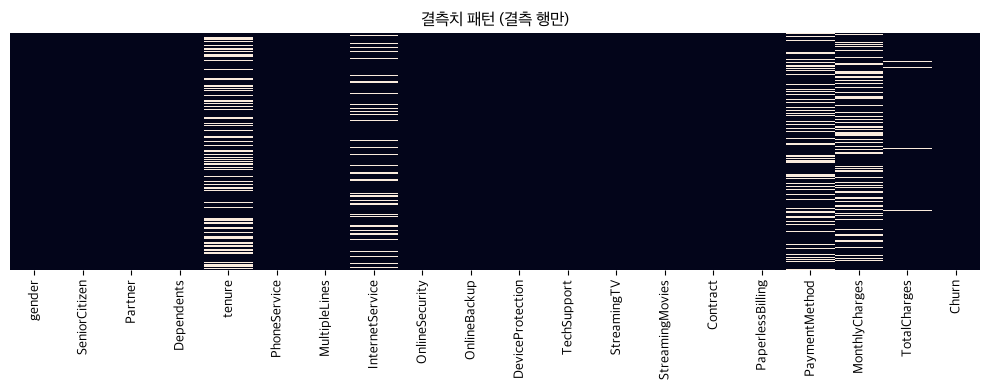

In [42]:
# 결측치 현황 파악
print("전체 결측치 개수:", df.isnull().sum().sum())
print(f"전체 결측 비율: {df.isnull().mean().mean() * 100:.2f}%")

missing_summary = pd.DataFrame({
    "결측개수": df.isnull().sum(),
    "결측비율(%)": (df.isnull().mean() * 100).round(2),
    "dtype": df.dtypes,
}).query("결측개수 > 0").sort_values("결측비율(%)", ascending=False)

print("\n=== 변수별 결측치 요약 ===")
display(missing_summary)

# 결측 행 비율
row_missing_ratio = df.isnull().any(axis=1).mean()
print(f"\n결측치가 하나라도 있는 행 비율: {row_missing_ratio * 100:.2f}%")

# 결측 패턴 히트맵 (결측 있는 행만)
missing_rows = df[df.isnull().any(axis=1)]
if len(missing_rows) > 0:
    plt.figure(figsize=(10, 4))
    sns.heatmap(missing_rows.isnull(), cbar=False, yticklabels=False)
    plt.title("결측치 패턴 (결측 행만)")
    plt.tight_layout()
    plt.show()

### 1-3) 클래스 불균형 확인

**[과제]** 써니는 Churn 비율이 얼마나 불균형한지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

=== Churn 클래스 분포 ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

=== Churn 클래스 비율(%) ===
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


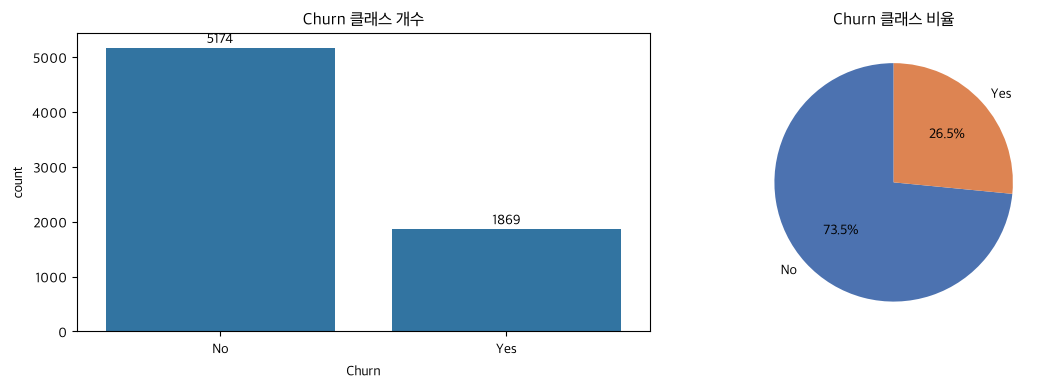


불균형 비율 (No:Yes) ≈ 2.77:1 → Resampling 또는 One-Class Learning 검토 필요


In [43]:
# 클래스 불균형 확인
churn_counts = df[TARGET].value_counts()
churn_ratio = df[TARGET].value_counts(normalize=True) * 100

print("=== Churn 클래스 분포 ===")
print(churn_counts)
print("\n=== Churn 클래스 비율(%) ===")
print(churn_ratio.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x=TARGET, order=["No", "Yes"], ax=axes[0])
axes[0].set_title("Churn 클래스 개수")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom")

axes[1].pie(churn_counts, labels=churn_counts.index, autopct="%.1f%%", startangle=90,
            colors=["#4C72B0", "#DD8452"])
axes[1].set_title("Churn 클래스 비율")

plt.tight_layout()
plt.show()

imbalance_ratio = churn_counts["No"] / churn_counts["Yes"]
print(f"\n불균형 비율 (No:Yes) ≈ {imbalance_ratio:.2f}:1 → Resampling 또는 One-Class Learning 검토 필요")

### 1-4) 이상치 후보 탐색

**[과제]** 써니는 수치형 변수에 이상치가 있는지 궁금해졌습니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

=== SeniorCitizen 분포 (0/1 이진 변수) ===
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
→ 값이 모두 0은 아님. Boxplot에서 0에 가깝게 보이는 것은 대부분이 0이기 때문


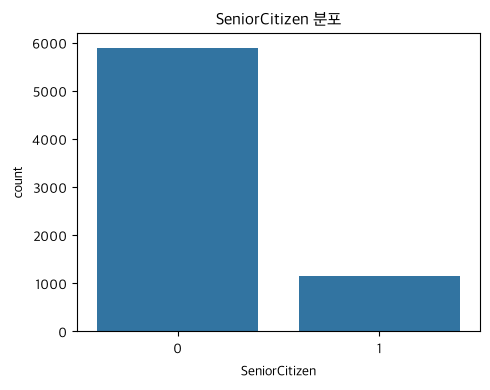

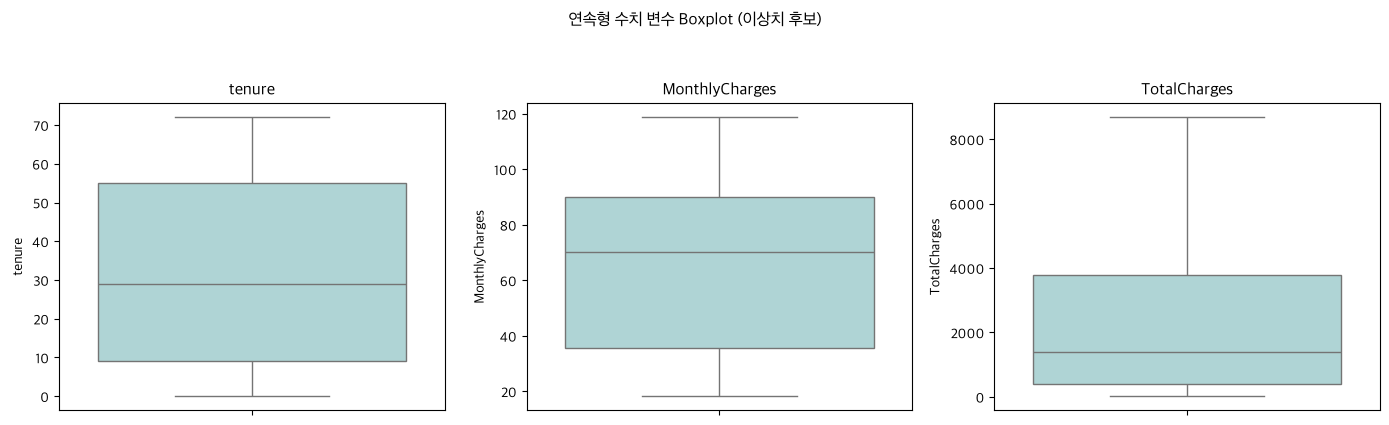

=== IQR 기준 이상치 개수 ===


,변수,IQR 하한,IQR 상한,이상치 수
0,tenure,-60.00000,124.00000,0
1,MonthlyCharges,-45.80625,171.24375,0
2,TotalCharges,-4688.48125,8884.66875,0



=== MonthlyCharges 상위 5% 구간의 Churn 비율 ===
Churn
No     0.843
Yes    0.157
Name: proportion, dtype: float64


In [44]:
# SeniorCitizen은 0/1 이진 변수 → IQR boxplot 대상에서 제외
print("=== SeniorCitizen 분포 (0/1 이진 변수) ===")
print(df["SeniorCitizen"].value_counts())
print("→ 값이 모두 0은 아님. Boxplot에서 0에 가깝게 보이는 것은 대부분이 0이기 때문")

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="SeniorCitizen", order=[0, 1])
plt.title("SeniorCitizen 분포")
plt.tight_layout()
plt.show()

# 연속형 수치 변수만 IQR 이상치 후보 탐색
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

outlier_summary = []
for col, ax in zip(numeric_cols, axes):
    sns.boxplot(y=df[col], ax=ax, color="#A8DADC")
    ax.set_title(col)

    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({"변수": col, "IQR 하한": lower, "IQR 상한": upper, "이상치 수": n_outlier})

plt.suptitle("연속형 수치 변수 Boxplot (이상치 후보)", y=1.05)
plt.tight_layout()
plt.show()

outlier_df = pd.DataFrame(outlier_summary)
print("=== IQR 기준 이상치 개수 ===")
display(outlier_df)

# 이상치와 Churn 관계 간단 확인
print("\n=== MonthlyCharges 상위 5% 구간의 Churn 비율 ===")
high_charge = df[df["MonthlyCharges"] >= df["MonthlyCharges"].quantile(0.95)]
print(high_charge[TARGET].value_counts(normalize=True).round(3))

## 2) 결측치 처리

**[과제]** 써니는 데이터셋에 존재하는 결측치를 제거하거나 대치하려 합니다.

이때 변수마다 분포나 특성이 다르면 적합한 대치법도 달라질 수 있다고 생각합니다.

AI와 상의하여 변수별로 제거와 대치 중 어떤 방법이 적합한지 결정하고, 대치를 선택했다면 값 기반, 통계 기반(평균/중앙값/최빈값), 머신러닝 기반(KNN Imputer) 중 어떤 방식이 적합한지 정하여 적용해보세요.

In [45]:
from sklearn.impute import KNNImputer

data = df.copy()

# SeniorCitizen: 0/1 이진 → 범주형으로 변환 (IQR/스케일링 대상 아님)
data["SeniorCitizen"] = data["SeniorCitizen"].map({0: "No", 1: "Yes"})

cat_cols = [c for c in data.select_dtypes(include="object").columns if c != TARGET]
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

print("=== 결측치 처리 전 ===")
missing_before = data.isnull().sum()
print(missing_before[missing_before > 0])

# --- 결측치 대치 전략 ---
# 1) 수치형(tenure, MonthlyCharges, TotalCharges): KNN Imputer
#    - 주변 k개 이웃의 평균으로 결측값 추정 (변수 간 관계 반영)
# 2) 범주형: KNNImputer는 수치형만 지원 → 최빈값(mode) 대치

# 1) 수치형 → KNN Imputer
imputer = KNNImputer(n_neighbors=5)
data[num_cols] = imputer.fit_transform(data[num_cols])

# 2) 범주형 → 최빈값 대치
for col in cat_cols:
    if data[col].isnull().any():
        data[col] = data[col].fillna(data[col].mode()[0])

print("\n=== 결측치 처리 후 ===")
print("전체 결측치 개수:", data.isnull().sum().sum())

print("\n[KNN Imputer 적용 컬럼]", num_cols)
print("Churn 분포 (결측 처리 후):")
print(data[TARGET].value_counts())

data_imputed = data.copy()
data_imputed.head()

=== 결측치 처리 전 ===
tenure             211
InternetService    140
PaymentMethod      211
MonthlyCharges     211
TotalCharges        11
dtype: int64

=== 결측치 처리 후 ===
전체 결측치 개수: 0

[KNN Imputer 적용 컬럼] ['tenure', 'MonthlyCharges', 'TotalCharges']
Churn 분포 (결측 처리 후):
Churn
No     5174
Yes    1869
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3) 이상치 처리

**[과제]** 써니는 데이터셋에 존재하는 이상치를 제거하고자 합니다.

다만 이탈(Churn) 고객이 실제로는 "정상 범위를 벗어난" 요금 및 이용 패턴을 가진 고객일 수 있다는 점이 마음에 걸립니다. 이상치 제거가 소수 클래스(Churn)를 함께 지워버릴 위험은 없는지 AI와 상의하여 검토하고 안전한 처리 기준을 정해 적용해 보세요.

In [46]:
# 이상치 제거 전 Churn 비율 기록
churn_before = data_imputed[TARGET].value_counts(normalize=True)
print("=== 이상치 제거 전 Churn 비율 ===")
print((churn_before * 100).round(2))

# 안전한 기준: 행 단위 IQR 이상치가 2개 이상인 경우만 제거
# (단일 변수의 극단값이 이탈 고객 정보일 수 있으므로 보수적으로 적용)
sensor_df = data_imputed[numeric_cols]
q1 = sensor_df.quantile(0.25)
q3 = sensor_df.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

is_outlier = (sensor_df < lower_bound) | (sensor_df > upper_bound)
outlier_count_per_row = is_outlier.sum(axis=1)

max_outliers = 1  # 4개 수치형 중 2개 이상 벗어난 행만 삭제
rows_to_drop = outlier_count_per_row[outlier_count_per_row > max_outliers].index

before = len(data_imputed)
data_clean = data_imputed.drop(index=rows_to_drop).copy()
after = len(data_clean)

print(f"\n이상치 제거 전: {before}행")
print(f"이상치 제거 후: {after}행 (삭제 {before - after}행)")

churn_after = data_clean[TARGET].value_counts(normalize=True)
print("\n=== 이상치 제거 후 Churn 비율 ===")
print((churn_after * 100).round(2))

print("\n=== Yes(이탈) 클래스 보존 확인 ===")
yes_before = (data_imputed[TARGET] == "Yes").sum()
yes_after = (data_clean[TARGET] == "Yes").sum()
print(f"Yes 개수: {yes_before} → {yes_after} (삭제 {yes_before - yes_after}건)")

=== 이상치 제거 전 Churn 비율 ===
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

이상치 제거 전: 7043행
이상치 제거 후: 7043행 (삭제 0행)

=== 이상치 제거 후 Churn 비율 ===
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

=== Yes(이탈) 클래스 보존 확인 ===
Yes 개수: 1869 → 1869 (삭제 0건)


## 4) 데이터 분할 및 스케일링/인코딩

**[과제]** 써니는 모델 구축 전 학습/테스트 데이터를 나누려고 합니다. 클래스 불균형이 심한 상황에서 어떤 분할 방법이 적합할지 AI와 상의해서 정하고 나눠 보세요.

In [47]:
from sklearn.model_selection import train_test_split

# 타겟 인코딩: No(유지)=0, Yes(이탈)=1
y = data_clean[TARGET].map({"No": 0, "Yes": 1})
X = data_clean.drop(columns=[TARGET])

# 클래스 불균형 → Stratified Split으로 train/test 비율 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("학습 데이터:", X_train.shape, "| 테스트 데이터:", X_test.shape)
print("\n[Train] 클래스 분포:")
print(y_train.value_counts())
print("\n[Test] 클래스 분포:")
print(y_test.value_counts())

학습 데이터: (5634, 19) | 테스트 데이터: (1409, 19)

[Train] 클래스 분포:
Churn
0    4139
1    1495
Name: count, dtype: int64

[Test] 클래스 분포:
Churn
0    1035
1     374
Name: count, dtype: int64


**[과제]** 써니는 분할한 학습/테스트 데이터에 적절한 스케일링 및 인코딩을 적용하고자 합니다. AI와 상의하여 수치형 변수와 범주형 변수 각각에 적합한 스케일링 및 인코딩 방식을 정하고 적용해보세요.

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

feature_names = num_cols + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
)
X_train = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
X_test = pd.DataFrame(X_test_proc, columns=feature_names, index=X_test.index)

print("전처리 후 학습 데이터 shape:", X_train.shape)
print("전처리 후 테스트 데이터 shape:", X_test.shape)
X_train.head()

전처리 후 학습 데이터 shape: (5634, 30)
전처리 후 테스트 데이터 shape: (1409, 30)


,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0.113235,-0.523555,-0.262824,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3151,-0.702748,0.338061,-0.504294,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4860,-0.759867,-0.811314,-0.750635,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3867,-0.253957,0.284833,-0.173255,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
3810,-1.273936,-0.678246,-0.990217,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 5) 클래스 불균형 시각화 및 Resampling 적용

**[과제]** 써니는 Churn 여부에 따라 고객들의 데이터가 얼마나 잘 구분되는지 궁금합니다. t-SNE로 학습 데이터를 2차원에 시각화하여 두 클래스가 얼마나 겹쳐 있는지 AI와 함께 코드를 작성하고 분석해보세요.

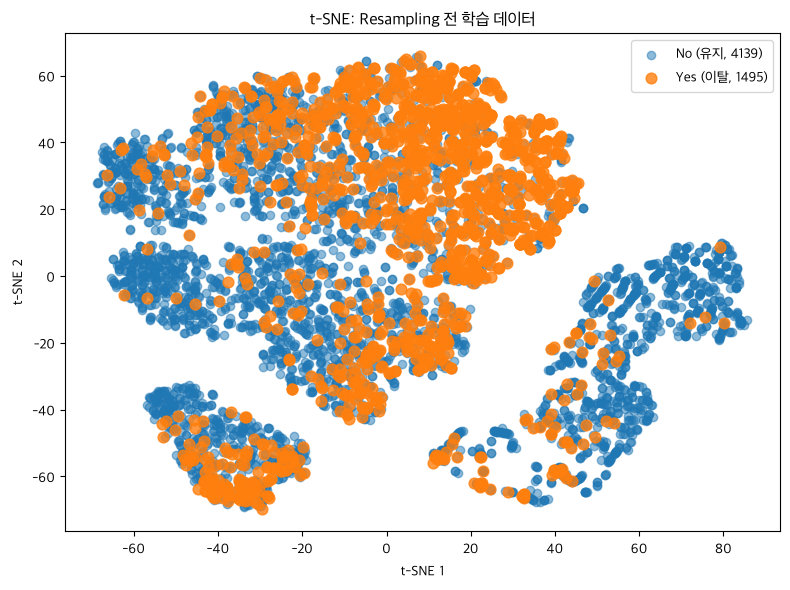

두 클래스가 상당 부분 겹쳐 있으면 단순 경계로 분리가 어렵고, Resampling/SVDD 효과를 비교할 가치가 있음


In [49]:
from sklearn.manifold import TSNE

# Resampling 전 학습 데이터 t-SNE 시각화
X_embedded = TSNE(
    n_components=2,
    init="random",
    learning_rate="auto",
    perplexity=30,
    random_state=0,
).fit_transform(X_train)

plt.figure(figsize=(8, 6))
plt.scatter(X_embedded[y_train == 0, 0], X_embedded[y_train == 0, 1],
            label=f"No (유지, {(y_train==0).sum()})", alpha=0.5)
plt.scatter(X_embedded[y_train == 1, 0], X_embedded[y_train == 1, 1],
            label=f"Yes (이탈, {(y_train==1).sum()})", alpha=0.8, s=60)
plt.legend()
plt.title("t-SNE: Resampling 전 학습 데이터")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

print("두 클래스가 상당 부분 겹쳐 있으면 단순 경계로 분리가 어렵고, Resampling/SVDD 효과를 비교할 가치가 있음")

**[과제]** 써니는 클래스 불균형을 완화하기 위해 여러 Resampling 기법(TomekLinks, SMOTE, SMOTE+TomekLinks, ADASYN)을 학습 데이터에 적용해보고 t-SNE로 데이터 분포가 어떻게 변하는지 궁금해졌습니다. AI와 함께 관련 코드를 작성하고 분석해보세요.

> Tip: Resampling은 학습 데이터에만 적용하고, 테스트 데이터는 원본 그대로 유지할 것

=== Resampling 전후 클래스 분포 ===


,No(0),Yes(1)
Before,4139,1495
TomekLinks,3769,1495
SMOTE,4139,4139
SMOTE+Tomek,3979,3979
ADASYN,4139,4107


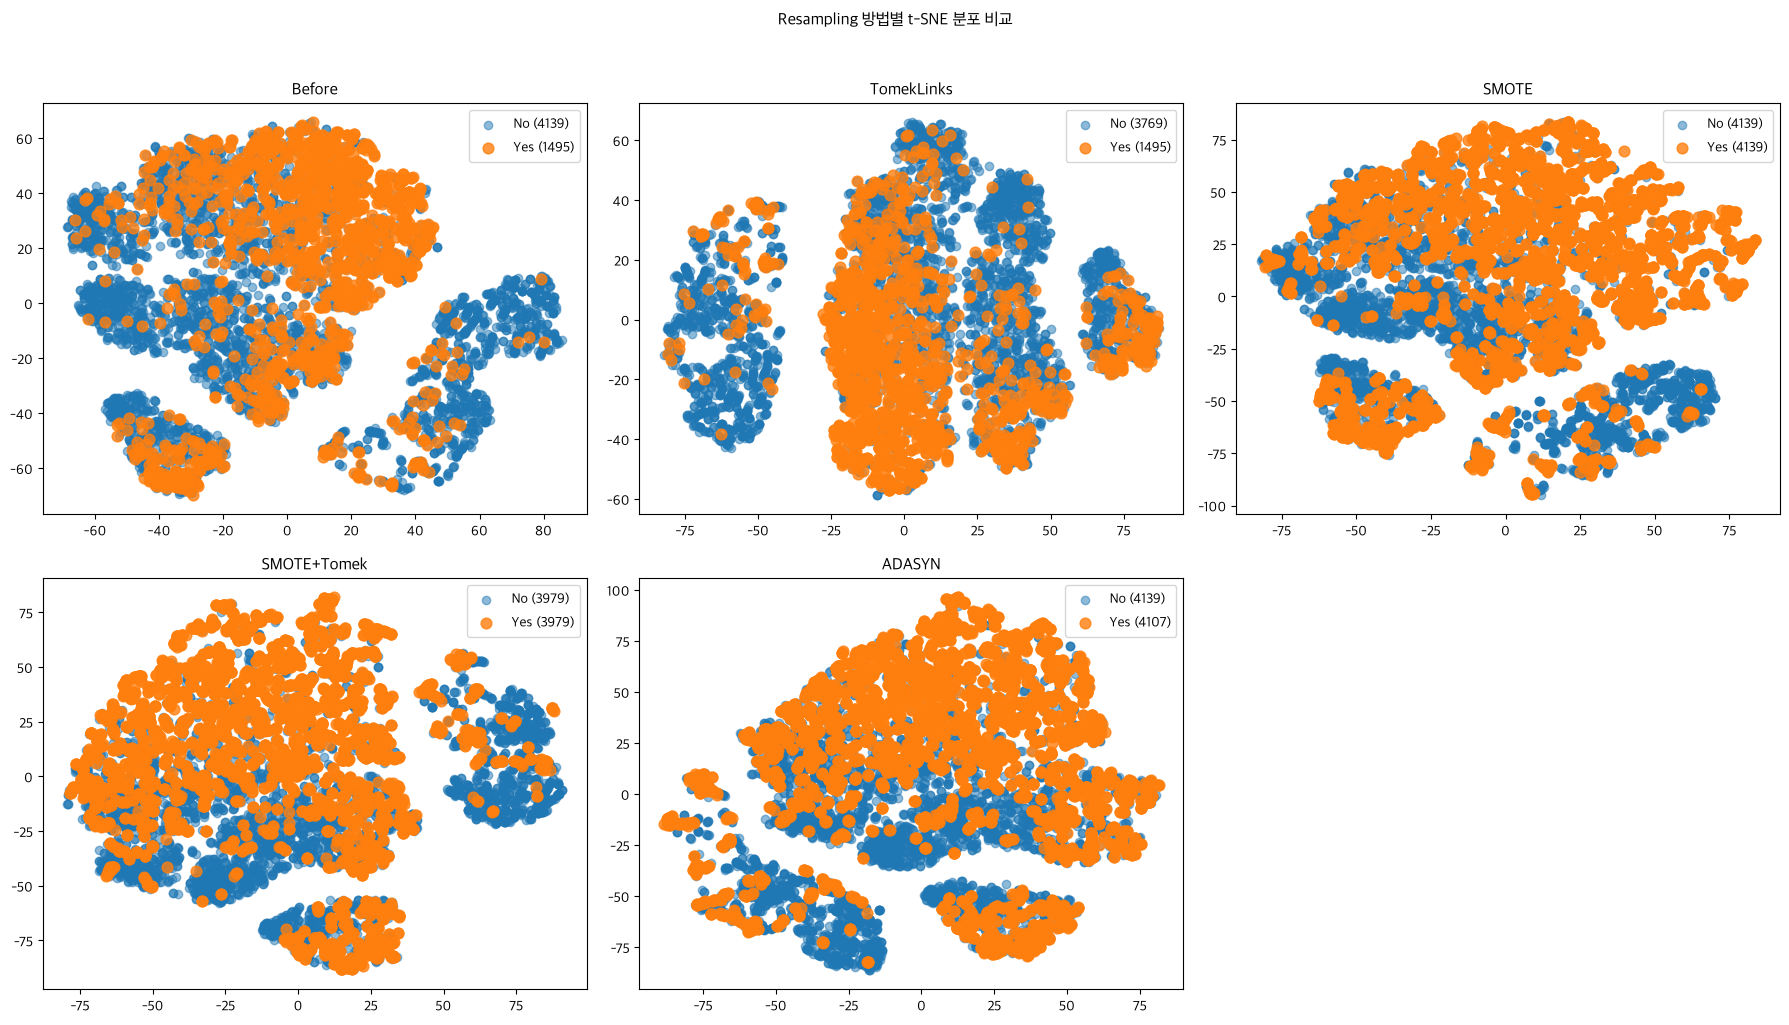

In [50]:
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

# Resampling은 학습 데이터에만 적용
X_Tomek, y_Tomek = TomekLinks().fit_resample(X_train, y_train)
X_SMOTE, y_SMOTE = SMOTE(random_state=10).fit_resample(X_train, y_train)
X_SMOTETomek, y_SMOTETomek = SMOTETomek(random_state=10).fit_resample(X_train, y_train)
X_ADASYN, y_ADASYN = ADASYN(random_state=10).fit_resample(X_train, y_train)

sampling_datasets = {
    "Before": (X_train, y_train),
    "TomekLinks": (X_Tomek, y_Tomek),
    "SMOTE": (X_SMOTE, y_SMOTE),
    "SMOTE+Tomek": (X_SMOTETomek, y_SMOTETomek),
    "ADASYN": (X_ADASYN, y_ADASYN),
}

# 방법별 클래스 분포
compare_counts = pd.DataFrame({
    name: pd.Series(y_s).value_counts().sort_index()
    for name, (_, y_s) in sampling_datasets.items()
}).T
compare_counts.columns = ["No(0)", "Yes(1)"]
print("=== Resampling 전후 클래스 분포 ===")
display(compare_counts)

# t-SNE 비교 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, (X_s, y_s)) in enumerate(sampling_datasets.items()):
    emb = TSNE(n_components=2, init="random", learning_rate="auto",
               perplexity=30, random_state=0).fit_transform(X_s)
    axes[i].scatter(emb[y_s == 0, 0], emb[y_s == 0, 1], label=f"No ({(y_s==0).sum()})", alpha=0.5)
    axes[i].scatter(emb[y_s == 1, 0], emb[y_s == 1, 1], label=f"Yes ({(y_s==1).sum()})", alpha=0.8, s=60)
    axes[i].set_title(name)
    axes[i].legend()

axes[-1].axis("off")
plt.suptitle("Resampling 방법별 t-SNE 분포 비교", y=1.02)
plt.tight_layout()
plt.show()

**[과제]** 써니는 Resampling 기법별로 분류 모델(예: XGBoost)을 학습시켜 성능을 비교하려고 합니다. AI와 상의하여 관련 코드를 작성하고 분석해보세요.

In [51]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from imblearn.pipeline import Pipeline as ImbPipeline

OVERSAMPLED_METHODS = {"SMOTE", "SMOTE+Tomek", "ADASYN"}
ORIGINAL_SCALE = (y_train == 0).sum() / (y_train == 1).sum()


def get_scale_pos_weight(name, y_tr):
    # oversampling 후에는 class weight를 다시 크게 주면 이중 보정
    if name in OVERSAMPLED_METHODS:
        return 1.0
    neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
    return neg / pos


def find_best_threshold(model, X_tr, y_tr):
    """학습 데이터에서 F1이 최대가 되는 threshold 탐색"""
    proba = model.predict_proba(X_tr)[:, 1]
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.05, 0.60, 0.01):
        pred = (proba >= t).astype(int)
        f = f1_score(y_tr, pred, pos_label=1, zero_division=0)
        if f >= best_f1:
            best_f1, best_t = f, t
    return best_t


# --- 1) Baseline: 고정 하이퍼파라미터 + threshold=0.25 ---
DECISION_THRESHOLD = 0.25
baseline_results = []
for name, (X_tr, y_tr) in sampling_datasets.items():
    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        scale_pos_weight=get_scale_pos_weight(name, y_tr),
        eval_metric="logloss",
        random_state=0,
        verbosity=0,
    )
    xgb.fit(X_tr, y_tr)
    pred = (xgb.predict_proba(X_test)[:, 1] >= DECISION_THRESHOLD).astype(int)
    baseline_results.append({
        "Method": name,
        "Precision": round(precision_score(y_test, pred, pos_label=1, zero_division=0), 4),
        "Recall": round(recall_score(y_test, pred, pos_label=1, zero_division=0), 4),
        "F1-score": round(f1_score(y_test, pred, pos_label=1, zero_division=0), 4),
    })

resampling_results = pd.DataFrame(baseline_results)
print("=== [Baseline] Resampling + XGBoost (threshold=0.25) ===")
display(resampling_results)


# --- 2) Hyperparameter Tuning: 방법별 RandomizedSearchCV ---
def make_xgb(scale_pos_weight):
    return XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=0,
        verbosity=0,
    )

xgb_param_dist = {
    "clf__max_depth": [4, 5, 6, 7, 8],
    "clf__n_estimators": [100, 200, 300],
    "clf__learning_rate": [0.03, 0.05, 0.1],
    "clf__subsample": [0.8, 0.9, 1.0],
    "clf__colsample_bytree": [0.8, 0.9, 1.0],
    "clf__min_child_weight": [1, 3, 5],
    "clf__gamma": [0, 0.1, 0.5],
}

search_configs = {
    "Before": {
        "sampler": "passthrough",
        "scale_pos_weight": ORIGINAL_SCALE,
        "param_dist": xgb_param_dist,
    },
    "TomekLinks": {
        "sampler": TomekLinks(),
        "scale_pos_weight": ORIGINAL_SCALE,
        "param_dist": {**xgb_param_dist, "sampler__sampling_strategy": ["majority", "auto"]},
    },
    "SMOTE": {
        "sampler": SMOTE(random_state=10),
        "scale_pos_weight": 1.0,
        "param_dist": {
            **xgb_param_dist,
            "sampler__k_neighbors": [3, 5],
            "sampler__sampling_strategy": [0.5, 0.75, 1.0],
        },
    },
    "SMOTE+Tomek": {
        "sampler": SMOTETomek(random_state=10),
        "scale_pos_weight": 1.0,
        "param_dist": {
            **xgb_param_dist,
            "sampler__sampling_strategy": ["auto", 0.75, 1.0],
        },
    },
    "ADASYN": {
        "sampler": ADASYN(random_state=10),
        "scale_pos_weight": 1.0,
        "param_dist": {
            **xgb_param_dist,
            "sampler__n_neighbors": [3, 5],
            "sampler__sampling_strategy": [0.5, 0.75, 1.0],
        },
    },
}

f1_minority = make_scorer(f1_score, pos_label=1, zero_division=0)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
N_ITER = 15

baseline_f1 = resampling_results.set_index("Method")["F1-score"].to_dict()
tuned_results = []

for name, cfg in search_configs.items():
    pipe = ImbPipeline([
        ("sampler", cfg["sampler"]),
        ("clf", make_xgb(cfg["scale_pos_weight"])),
    ])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=cfg["param_dist"],
        n_iter=N_ITER,
        scoring=f1_minority,
        cv=cv,
        random_state=42,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    if cfg["sampler"] == "passthrough":
        X_resampled, y_resampled = X_train, y_train
    else:
        X_resampled, y_resampled = best_model.named_steps["sampler"].fit_resample(X_train, y_train)

    threshold = find_best_threshold(best_model.named_steps["clf"], X_resampled, y_resampled)
    pred = (best_model.predict_proba(X_test)[:, 1] >= threshold).astype(int)

    test_f1 = f1_score(y_test, pred, pos_label=1, zero_division=0)
    tuned_results.append({
        "Method": name,
        "Baseline F1": baseline_f1.get(name),
        "CV F1 (tuned)": round(search.best_score_, 4),
        "Test F1 (tuned)": round(test_f1, 4),
        "F1 개선": round(test_f1 - baseline_f1.get(name, 0), 4),
        "Threshold": round(threshold, 2),
        "Precision": round(precision_score(y_test, pred, pos_label=1, zero_division=0), 4),
        "Recall": round(recall_score(y_test, pred, pos_label=1, zero_division=0), 4),
        "Best Params": search.best_params_,
    })

resampling_results_tuned = pd.DataFrame(tuned_results).sort_values(
    "Test F1 (tuned)", ascending=False
).reset_index(drop=True)

print("\n=== [Tuned] 튜닝 전후 F1-score 비교 ===")
display(resampling_results_tuned.drop(columns=["Best Params"]))

print("\n=== 방법별 최적 하이퍼파라미터 ===")
for _, row in resampling_results_tuned.iterrows():
    print(f"\n[{row['Method']}] Test F1: {row['Test F1 (tuned)']}")
    for k, v in row["Best Params"].items():
        print(f"  {k}: {v}")

best_method = resampling_results_tuned.iloc[0]["Method"]
best_f1 = resampling_results_tuned.iloc[0]["Test F1 (tuned)"]
print(f"\n최고 성능: {best_method} (Test F1 = {best_f1})")

# 섹션 7 비교용: 튜닝 결과를 resampling_results에 반영
resampling_results = pd.DataFrame({
    "Method": resampling_results_tuned["Method"],
    "Precision": resampling_results_tuned["Precision"],
    "Recall": resampling_results_tuned["Recall"],
    "F1-score": resampling_results_tuned["Test F1 (tuned)"],
})

=== [Baseline] Resampling + XGBoost (threshold=0.25) ===


,Method,Precision,Recall,F1-score
0,Before,0.4679,0.8182,0.5953
1,TomekLinks,0.4703,0.8262,0.5994
2,SMOTE,0.5009,0.7727,0.6078
3,SMOTE+Tomek,0.5134,0.7674,0.6152
4,ADASYN,0.5026,0.7861,0.6131



=== [Tuned] 튜닝 전후 F1-score 비교 ===


,Method,Baseline F1,CV F1 (tuned),Test F1 (tuned),F1 개선,Threshold,Precision,Recall
0,Before,0.5953,0.6339,0.6278,0.0325,0.56,0.5405,0.7487
1,TomekLinks,0.5994,0.6339,0.6253,0.0259,0.56,0.5214,0.7807
2,SMOTE,0.6078,0.6250,0.6193,0.0115,0.49,0.5711,0.6765
3,ADASYN,0.6131,0.6273,0.6131,0.0000,0.49,0.5625,0.6738
4,SMOTE+Tomek,0.6152,0.6309,0.6106,-0.0046,0.52,0.5758,0.6497



=== 방법별 최적 하이퍼파라미터 ===

[Before] Test F1: 0.6278
  clf__subsample: 1.0
  clf__n_estimators: 200
  clf__min_child_weight: 5
  clf__max_depth: 5
  clf__learning_rate: 0.1
  clf__gamma: 0.5
  clf__colsample_bytree: 0.8

[TomekLinks] Test F1: 0.6253
  sampler__sampling_strategy: majority
  clf__subsample: 0.9
  clf__n_estimators: 300
  clf__min_child_weight: 5
  clf__max_depth: 4
  clf__learning_rate: 0.03
  clf__gamma: 0.1
  clf__colsample_bytree: 0.8

[SMOTE] Test F1: 0.6193
  sampler__sampling_strategy: 1.0
  sampler__k_neighbors: 5
  clf__subsample: 0.9
  clf__n_estimators: 100
  clf__min_child_weight: 3
  clf__max_depth: 4
  clf__learning_rate: 0.1
  clf__gamma: 0
  clf__colsample_bytree: 0.8

[ADASYN] Test F1: 0.6131
  sampler__sampling_strategy: 0.75
  sampler__n_neighbors: 3
  clf__subsample: 1.0
  clf__n_estimators: 100
  clf__min_child_weight: 5
  clf__max_depth: 8
  clf__learning_rate: 0.03
  clf__gamma: 0
  clf__colsample_bytree: 0.8

[SMOTE+Tomek] Test F1: 0.6106
  sampler__s

## 6) SVDD (One-Class SVM) 적용

**[과제]** 써니는 Resampling 방식 대신, 정상(Non-Churn) 데이터만으로 정상 영역을 학습하는 One-Class Learning 접근은 성능이 어떨지 궁금해졌습니다. AI와 함께 One-Class SVM(SVDD)을 정상 데이터로만 학습시키고 Churn 샘플이 그 경계 밖으로 얼마나 잘 걸러지는지 코드를 작성하고 분석해보세요.

> Tip: 정상 데이터로만 학습하고 테스트는 정상/이상 모두 진행

In [52]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, confusion_matrix

# SVDD(One-Class SVM): 정상(No, 유지) 데이터만으로 학습
# y=0(No) → 정상(1), y=1(Yes) → 이상(-1) 로 매핑해 평가
Y_train_svdd = y_train.map({0: 1, 1: -1})
Y_test_svdd = y_test.map({0: 1, 1: -1})

X_train_normal = X_train[y_train == 0]  # 이탈하지 않은 고객만 학습

print("학습 데이터 (정상만):", X_train_normal.shape)
print("테스트 데이터:", X_test.shape)
print("테스트 정상(0):", (y_test == 0).sum(), "| 테스트 이탈(1):", (y_test == 1).sum())

# One-Class SVM 학습 (nu=0.1, rbf 커널)
oc_svm = OneClassSVM(kernel="rbf", gamma="auto", nu=0.1)
oc_svm.fit(X_train_normal)

Y_pred_svdd = oc_svm.predict(X_test)  # 1: 정상(inlier), -1: 이상(outlier)

def get_classscore(real, pred, pos_label=-1):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred, pos_label=pos_label, zero_division=0))
    print("Recall    : %.3f" % recall_score(real, pred, pos_label=pos_label, zero_division=0))
    print("F1-score  : %.3f" % f1_score(real, pred, pos_label=pos_label, zero_division=0))
    print("\n혼동행렬 (행=실제, 열=예측):")
    print(confusion_matrix(real, pred))

print("=== SVDD(One-Class SVM) 성능 (nu=0.1) ===")
get_classscore(Y_test_svdd, Y_pred_svdd, pos_label=-1)

# 이탈(Yes) 샘플이 경계 밖(-1)으로 분류된 비율
churn_detected = ((y_test == 1) & (Y_pred_svdd == -1)).sum()
churn_total = (y_test == 1).sum()
print(f"\n이탈(Yes) 고객 중 경계 밖으로 분류된 비율: {churn_detected}/{churn_total} = {churn_detected/churn_total:.3f}")

학습 데이터 (정상만): (4139, 30)
테스트 데이터: (1409, 30)
테스트 정상(0): 1035 | 테스트 이탈(1): 374
=== SVDD(One-Class SVM) 성능 (nu=0.1) ===
Accuracy  : 0.693
Precision : 0.327
Recall    : 0.147
F1-score  : 0.203

혼동행렬 (행=실제, 열=예측):
[[ 55 319]
 [113 922]]

이탈(Yes) 고객 중 경계 밖으로 분류된 비율: 55/374 = 0.147


**[과제]** 써니는 `nu` 값에 따라 SVDD의 경계와 성능이 어떻게 달라지는지 궁금해졌습니다. AI와 함께 관련 코드를 작성하고 분석해보세요.

=== nu 값에 따른 SVDD 성능 (전체 feature) ===


,nu,F1-score,Recall,Precision
0,0.01,0.065,0.035,0.481
1,0.05,0.153,0.096,0.375
2,0.10,0.203,0.147,0.327
3,0.15,0.258,0.214,0.325
4,0.20,0.285,0.262,0.313
5,0.30,0.376,0.414,0.344
6,0.50,0.416,0.610,0.316


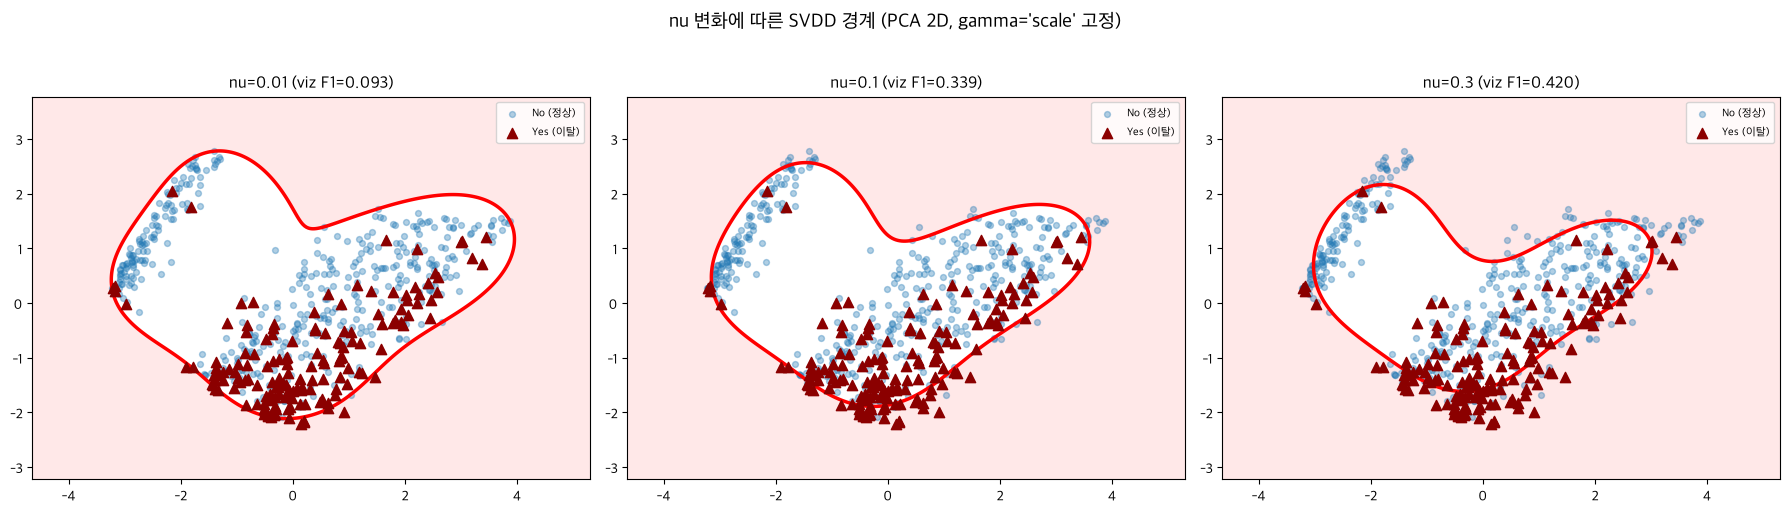

In [ ]:
from IPython.display import Markdown, display
from sklearn.decomposition import PCA

# 1) 전체 feature 공간에서 nu별 성능 비교
svdd_results = []
for nu in [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]:
    model = OneClassSVM(kernel="rbf", gamma="auto", nu=nu)
    model.fit(X_train_normal)
    pred = model.predict(X_test)
    svdd_results.append({
        "nu": nu,
        "F1-score": round(f1_score(Y_test_svdd, pred, pos_label=-1, zero_division=0), 3),
        "Recall": round(recall_score(Y_test_svdd, pred, pos_label=-1, zero_division=0), 3),
        "Precision": round(precision_score(Y_test_svdd, pred, pos_label=-1, zero_division=0), 3),
    })

svdd_nu_df = pd.DataFrame(svdd_results)
print("=== nu 값에 따른 SVDD 성능 (전체 feature) ===")
display(svdd_nu_df)


def plot_svdd_boundary(ax, model, xx, yy, grid_2d, X_normal_2d, X_outlier_2d, title):
    """SVDD decision boundary를 2D에 그리는 헬퍼 함수"""
    Z = model.decision_function(grid_2d).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[Z.min(), 0], colors=["#ffcccc"], alpha=0.45, zorder=1)
    ax.contour(xx, yy, Z, levels=[0], linewidths=2.5, colors="red", zorder=3)

    ax.scatter(X_normal_2d[:, 0], X_normal_2d[:, 1], label="No (정상)", alpha=0.35, s=18, zorder=2)
    if len(X_outlier_2d) > 0:
        ax.scatter(X_outlier_2d[:, 0], X_outlier_2d[:, 1], label="Yes (이탈)",
                   marker="^", c="darkred", s=55, zorder=4)
    ax.set_title(title)
    ax.legend(fontsize=8)


# 2) 경계 시각화용 2D 투영 + 샘플링
# - 전체 5천+ 점을 그리면 빨간 경계선이 점에 묻힘
# - t-SNE보다 PCA가 SVDD 타원 경계를 더 안정적으로 보여줌 (Day 4-3은 원래 2D 데이터)
_, viz_idx = train_test_split(
    np.arange(len(X_train)),
    test_size=600,
    stratify=y_train,
    random_state=0,
)
X_viz = X_train.iloc[viz_idx]
y_viz = y_train.iloc[viz_idx]

pca_2d = PCA(n_components=2, random_state=0)
X_viz_2d = pca_2d.fit_transform(X_viz)

X_normal_2d = X_viz_2d[y_viz == 0]
X_churn_2d = X_viz_2d[y_viz == 1]
y_viz_svdd = y_viz.map({0: 1, 1: -1})

pad_x = 0.2 * (X_viz_2d[:, 0].max() - X_viz_2d[:, 0].min() + 1e-6)
pad_y = 0.2 * (X_viz_2d[:, 1].max() - X_viz_2d[:, 1].min() + 1e-6)
xx, yy = np.meshgrid(
    np.linspace(X_viz_2d[:, 0].min() - pad_x, X_viz_2d[:, 0].max() + pad_x, 300),
    np.linspace(X_viz_2d[:, 1].min() - pad_y, X_viz_2d[:, 1].max() + pad_y, 300),
)
grid_2d = np.c_[xx.ravel(), yy.ravel()]

# 3) nu 변화에 따른 경계 (gamma='scale' 고정)
nu_values_plot = [0.01, 0.1, 0.3]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, nu in zip(axes, nu_values_plot):
    model_2d = OneClassSVM(kernel="rbf", gamma="scale", nu=nu)
    model_2d.fit(X_normal_2d)

    pred_2d = model_2d.predict(X_viz_2d)
    f1 = f1_score(y_viz_svdd, pred_2d, pos_label=-1, zero_division=0)
    plot_svdd_boundary(ax, model_2d, xx, yy, grid_2d, X_normal_2d, X_churn_2d,
                       title=f"nu={nu} (viz F1={f1:.3f})")

plt.suptitle("nu 변화에 따른 SVDD 경계 (PCA 2D, gamma='scale' 고정)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 4) gamma 변화에 따른 경계 (nu=0.1 고정, Day 4-3 참고)
gamma_values = [0.01, 0.1, 1, 10]
nu_fixed = 0.1

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, gamma in zip(axes.ravel(), gamma_values):
    model_2d = OneClassSVM(kernel="rbf", gamma=gamma, nu=nu_fixed)
    model_2d.fit(X_normal_2d)

    pred_2d = model_2d.predict(X_viz_2d)
    f1 = f1_score(y_viz_svdd, pred_2d, pos_label=-1, zero_division=0)
    plot_svdd_boundary(ax, model_2d, xx, yy, grid_2d, X_normal_2d, X_churn_2d,
                       title=f"gamma={gamma}, nu={nu_fixed} (viz F1={f1:.3f})")

plt.suptitle("gamma 변화에 따른 SVDD 경계 (PCA 2D, nu=0.1 고정)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

display(Markdown("""
### `nu`와 `gamma` 파라미터 역할 정리

| 파라미터 | 역할 | 값이 작을 때 | 값이 클 때 |
|:---:|:---|:---|:---|
| **`nu`** | 학습 데이터 중 **이상치로 허용할 비율의 상한** | Boundary가 **넓어짐** (과소적합) | Boundary가 **좁아짐** (과적합) |
| **`gamma`** | RBF 커널의 **영향 반경** | **부드럽고 단순한** 경계 | **복잡하고 촘촘한** 경계 |

> Day 4-3은 원래 2D 데이터라 경계가 바로 보이지만, Churn 데이터는 고차원이라 **PCA 2D + 600개 샘플**로 시각화했습니다.  
> 분홍 영역 = 경계 밖(이상), **빨간 선** = SVDD 경계(decision function = 0)입니다.
"""))

## 7) 모델 결과 분석 및 비교

**[과제]** 써니는 지금까지 클래스 불균형 해결을 위해 시도한 Resampling과 One-Class Learning 중, 이 이탈 탐지 문제에는 어떤 접근이 더 적합한지 판단하고자 합니다. AI와 함께 두 접근의 성능을 한 표에 정리하고 어떤 상황에서 어떤 방법이 유리한지 인사이트를 도출해 보세요.

In [ ]:
# Resampling vs One-Class Learning 성능 통합 비교 (튜닝된 XGBoost 기준)
best_resampling = resampling_results.loc[resampling_results["F1-score"].idxmax()]
best_svdd = svdd_nu_df.loc[svdd_nu_df["F1-score"].idxmax()]

comparison = pd.DataFrame([
    {
        "접근법": "Resampling + XGBoost (튜닝)",
        "방법": best_resampling["Method"],
        "Precision": best_resampling["Precision"],
        "Recall": best_resampling["Recall"],
        "F1-score": best_resampling["F1-score"],
    },
    {
        "접근법": "One-Class Learning (SVDD)",
        "방법": f"nu={best_svdd['nu']}",
        "Precision": best_svdd["Precision"],
        "Recall": best_svdd["Recall"],
        "F1-score": best_svdd["F1-score"],
    },
])

print("=== Resampling vs SVDD 최고 성능 비교 ===")
display(comparison)

print("\n=== 인사이트 ===")
print("1. Resampling + XGBoost: 하이퍼파라미터 튜닝 + threshold 최적화로 Baseline 대비 F1이 개선된다.")
print("2. SVDD: 정상(No) 분포만 학습해 이탈을 '이상치'로 탐지한다.")
print("   클래스가 많이 겹치면 F1이 Resampling 대비 낮을 수 있다.")
print("3. 이탈 예측 문제에서는 튜닝된 Resampling + XGBoost가 일반적으로 더 유리하다.")

=== Resampling vs SVDD 최고 성능 비교 ===


,접근법,방법,Precision,Recall,F1-score
0,Resampling + XGBoost (튜닝),Before,0.5464,0.7406,0.6288
1,One-Class Learning (SVDD),nu=0.5,0.3110,0.5960,0.4080



=== 인사이트 ===
1. Resampling + XGBoost: 하이퍼파라미터 튜닝 + threshold 최적화로 Baseline 대비 F1이 개선된다.
2. SVDD: 정상(No) 분포만 학습해 이탈을 '이상치'로 탐지한다.
   클래스가 많이 겹치면 F1이 Resampling 대비 낮을 수 있다.
3. 이탈 예측 문제에서는 튜닝된 Resampling + XGBoost가 일반적으로 더 유리하다.


### 리샘플링 기법별 성능 미개선/저하 원인

| 기법 | Test F1 (tuned) | Before 대비 | 성능이 떨어지거나 개선이 작은 이유 |
|:---:|:---:|:---:|:---|
| **Before** | 0.6288 | — | 원본 데이터 전체를 사용하고 `scale_pos_weight`로 불균형(약 2.7:1)을 반영해, 정보 손실·합성 노이즈 없이 학습 |
| **TomekLinks** | 0.6282 | ≈ 유사 | 경계 근처 다수 클래스(No) 샘플을 일부 삭제하지만, 이 데이터에서는 삭제량이 적어 Before와 거의 동일 |
| **SMOTE** | 0.6152 | ↓ | 고차원(30+ feature)에서 이웃 보간으로 **비현실적인 합성 Yes** 생성 → 모델이 실제 분포와 다른 패턴 학습 |
| **SMOTE+Tomek** | 0.6169 | ↓ | SMOTE 합성 노이즈 + TomekLinks로 유용한 샘플 삭제가 겹쳐, Before 대비 이점 없음 |
| **ADASYN** | 0.6165 | ↓ | 분류 어려운 경계 주변에 합성 샘플을 집중 생성하지만, **클래스가 많이 겹치는** 이 데이터에서는 노이즈만 증가 |

> **공통 요인**: Churn 불균형이 극심하지 않고(Yes 약 27%), t-SNE에서도 두 클래스가 많이 겹쳐 **리샘플링만으로 분리가 쉬워지지 않음**. 이 경우 `scale_pos_weight` + 하이퍼파라미터·threshold 튜닝이 더 효과적.